# RAG Multimodal con Mistral OCR 3 y Gemini Embeddings
## Construye un sistema de preguntas y respuestas sobre documentos PDF que entiende texto **e imágenes**

---

### ¿Qué vas a construir?

Un pipeline completo de **Retrieval-Augmented Generation (RAG) multimodal** que:

1. Lee un PDF con Mistral OCR 3 → extrae texto estructurado e imágenes embebidas  
2. Enriquece cada imagen con una descripción semántica usando Gemini  
3. Genera embeddings multimodales (texto + imagen) en el mismo espacio vectorial con Gemini Embeddings  
4. Indexa todo en ChromaDB con metadatos de tipo  
5. Responde preguntas recuperando texto **e imágenes** de forma garantizada (dual retrieval)

---

### Arquitectura del Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│                        PDF de entrada                           │
└──────────────────────────┬──────────────────────────────────────┘
                           │
                    ┌──────▼───────┐
                    │  Mistral OCR │  → Markdown + imágenes en Base64
                    └──────┬───────┘
                           │
              ┌────────────┴─────────────┐
              │                          │
       ┌──────▼───────┐          ┌───────▼───────┐
       │  Texto limpio│          │   Imágenes    │
       │  (Markdown)  │          │  + descripción│
       └──────┬───────┘          │  por Gemini   │
              │                  └───────┬───────┘
       ┌──────▼───────┐          ┌───────▼──────┐
       │   Chunking   │          │  Embedding   │
       │  (solapado)  │          │  multimodal  │
       └──────┬───────┘          └───────┬──────┘
              │                          │
       ┌──────▼───────┐                  │
       │  Embedding   │                  │
       │   de texto   │                  │
       └──────┬───────┘                  │
              └────────────┬─────────────┘
                    ┌──────▼───────┐
                    │   ChromaDB   │  type="text" | type="image"
                    └──────┬───────┘
                           │
                    ┌──────▼────────┐
                    │ Dual Retrieval│  → k_text chunks + k_images imágenes
                    └──────┬────────┘
                           │
                    ┌──────▼───────┐
                    │ Gemini 2.5   │  → Respuesta multimodal
                    │    Flash     │
                    └──────────────┘
```

---

### Conceptos clave que aprenderás

| Concepto | ¿Qué es? |
|---|---|
| **Mistral OCR 3** | OCR de última generación que extrae texto estructurado e imágenes de PDFs |
| **Embeddings multimodales** | Vectores que representan texto e imágenes en el **mismo espacio semántico** |
| **Dual Retrieval** | Consultar texto e imágenes por separado para garantizar recuperación balanceada |
| **ChromaDB con metadata** | Base de datos vectorial con filtros por tipo de contenido |
| **RAG con visión** | Pasar imágenes como contexto directo a un modelo multimodal |

---

> **Requisitos:** Una clave de API de [Mistral](https://console.mistral.ai/api-keys/) y una de [Google AI Studio](https://aistudio.google.com/apikey). Un PDF local para procesar.


In [1]:
!pip install mistralai google-genai chromadb ipython pandas tqdm

## 0. Prerrequisitos y Configuración

### 0.1 Instalación de dependencias

### 0.2 Autenticación con las APIs

Necesitas dos claves:
- **`MISTRAL_API_KEY`** → para el OCR ([Mistral AI Studio](https://console.mistral.ai/api-keys/))  
- **`GEMINI_API_KEY`** → para embeddings y generación ([Google AI Studio](https://aistudio.google.com/apikey))

In [1]:
import os
import base64
import re
from IPython.display import Markdown, display
from google import genai
from google.genai import types
from dotenv import load_dotenv

load_dotenv()

MISTRAL_API_KEY = os.environ.get("MISTRAL_API_KEY", "TU-API-KEY")
GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY",  "TU-API-KEY")

if "REEMPLAZA" in MISTRAL_API_KEY or "REEMPLAZA" in GEMINI_API_KEY:
    print("⚠️ ADVERTENCIA: Asegúrate de reemplazar las API Keys con valores reales.")
else:
    print("✅ Claves de API detectadas. Listo para continuar.")

try:
    gemini_client = genai.Client(api_key=GEMINI_API_KEY)
    print("✅ Gemini Client Inicializado.")
except:
    pass

✅ Claves de API detectadas. Listo para continuar.
✅ Gemini Client Inicializado.


## 1. Extracción de Contenido con Mistral OCR 3

### ¿Por qué Mistral OCR 3?

Un LLM no puede "ver" directamente un PDF binario. Necesitamos un paso previo que convierta el documento en información estructurada. Mistral OCR 3 hace esto con una ventaja clave para RAG multimodal:

> **`include_image_base64=True`** → cada imagen del PDF se devuelve como `Base64` embebida en el objeto de respuesta. Así no perdemos ninguna figura, gráfica o fotografía del documento.

**Resultado que obtenemos:**
```
ocr_response.pages[i].markdown  →  Texto de la página en formato Markdown
ocr_response.pages[i].images    →  Lista de imágenes con id + base64
```

### 1.1 Procesar el documento

In [2]:
from mistralai import Mistral

mistral_client = Mistral(api_key=MISTRAL_API_KEY)

PDF_PATH = "385908-01.pdf"  # ← Reemplaza con la ruta a tu PDF

def pdf_to_base64(filepath: str) -> str | None:
    """Convierte un PDF a string Base64 para enviarlo como data URL."""
    try:
        with open(filepath, "rb") as f:
            return base64.b64encode(f.read()).decode("utf-8")
    except FileNotFoundError:
        print(f"❌ Archivo no encontrado: {filepath}")
        return None

base64_pdf   = pdf_to_base64(PDF_PATH)
markdown_text = ""

if base64_pdf:
    print(f"📄 Procesando '{PDF_PATH}' con Mistral OCR 3...")
    ocr_response = mistral_client.ocr.process(
        model="mistral-ocr-latest",
        document={
            "type": "document_url",
            "document_url": f"data:application/pdf;base64,{base64_pdf}",
        },
        include_image_base64=True,   # ← CRÍTICO: recupera imágenes embebidas
    )
    # Unir el Markdown de todas las páginas en un solo string
    markdown_text = "\n\n".join(page.markdown for page in ocr_response.pages)

    total_imagenes = sum(len(p.images) for p in ocr_response.pages)
    print(f"✅ OCR completado → {len(ocr_response.pages)} páginas | {total_imagenes} imágenes detectadas")


📄 Procesando '385908-01.pdf' con Mistral OCR 3...
✅ OCR completado → 14 páginas | 84 imágenes detectadas


In [6]:
import pandas as pd
pd.DataFrame(ocr_response.pages)

,0,1,2,3
0,"(index, 0)","(markdown, # dyson outsize\n\nManual de usuari...","(images, [id='img-0.jpeg' top_left_x=66 top_le...","(dimensions, dpi=200 height=2339 width=1654)"
1,"(index, 1)","(markdown, 2\n\n# Qué contiene la caja\n\nAlgu...","(images, [id='img-1.jpeg' top_left_x=72 top_le...","(dimensions, dpi=200 height=2339 width=1654)"
2,"(index, 2)","(markdown, Montaje de la máquina\n\n![img-18.j...","(images, [id='img-18.jpeg' top_left_x=72 top_l...","(dimensions, dpi=200 height=2339 width=1654)"
3,"(index, 3)","(markdown, Pantalla LCD\n\n![img-25.jpeg](img-...","(images, [id='img-25.jpeg' top_left_x=72 top_l...","(dimensions, dpi=200 height=2339 width=1654)"
4,"(index, 4)","(markdown, 5\n\n# Cómo cargar tu máquina\n\nEs...","(images, [id='img-32.jpeg' top_left_x=66 top_l...","(dimensions, dpi=200 height=2339 width=1654)"
5,"(index, 5)","(markdown, Vaciado del cubo\n\nVacía el cubo e...","(images, [id='img-35.jpeg' top_left_x=1075 top...","(dimensions, dpi=200 height=2339 width=1654)"
6,"(index, 6)","(markdown, Lavado del filtro\n\nPara asegurart...","(images, [id='img-42.jpeg' top_left_x=66 top_l...","(dimensions, dpi=200 height=2339 width=1654)"
7,"(index, 7)","(markdown, Lavado del cepillo High Torque XL\n...","(images, [id='img-50.jpeg' top_left_x=72 top_l...","(dimensions, dpi=200 height=2339 width=1654)"
8,"(index, 8)","(markdown, Lavado del cepillo Dyson Laser Slim...","(images, [id='img-58.jpeg' top_left_x=446 top_...","(dimensions, dpi=200 height=2339 width=1654)"
9,"(index, 9)","(markdown, Lavado del cepillo suave giratorio\...","(images, [id='img-61.jpeg' top_left_x=66 top_l...","(dimensions, dpi=200 height=2339 width=1654)"


### 1.2 Vista previa del resultado OCR

Antes de continuar, es útil ver qué produjo Mistral OCR. El output es Markdown estructurado: encabezados, tablas, listas y referencias a imágenes. Este Markdown es la materia prima de todo el pipeline.

In [7]:
# Vista previa del Markdown generado por Mistral OCR
if markdown_text:
    lineas = markdown_text.split("\n")
    total_palabras = len(markdown_text.split())
    total_imagenes_ref = markdown_text.count("![")  # Referencias de imagen en el Markdown

    print(f"📊 Estadísticas del Markdown OCR:")
    print(f"   Total de líneas   : {len(lineas)}")
    print(f"   Total de palabras : {total_palabras:,}")
    print(f"   Referencias de imagen encontradas: {total_imagenes_ref}")
    print()
    print("─── Primeras 50 líneas del Markdown ───")
    print("\n".join(lineas[:50]))
    print("... (continúa)")


📊 Estadísticas del Markdown OCR:
   Total de líneas   : 650
   Total de palabras : 2,941
   Referencias de imagen encontradas: 84

─── Primeras 50 líneas del Markdown ───
# dyson outsize

Manual de usuario

![img-0.jpeg](img-0.jpeg)

- Qué contiene la caja
- Montaje de la máquina
- Cómo empezar
- Cuidado de suelos
- Pantalla LCD
- Cómo cargar tu máquina
- Cambio de la batería intercambiable
- Vaciado del cubo
- Limpieza del cubo
- Lavado del filtro
- Lavado del cepillo High Torque XL
- Lavado del cepillo Dyson Laser Slim Fluffy™
- Lavado del cepillo suave giratorio
- Lavado de los accesorios
- Uso del cepillo High Torque XL
- Buscar obstrucciones
- Cómo eliminar bloqueos en el cabezal de limpieza del cepillo suave
- Eliminación de obstrucciones del accesorio para pelo

2

# Qué contiene la caja

Algunos accesorios pueden no estar incluidos. Puedes comprar accesorios adicionales en www.dyson.es

![img-1.jpeg](img-1.jpeg)
Cuerpo principal de la aspiradora

![img-2.jpeg](img-2.jpeg)
Cepil

## 2. Separar Texto e Imágenes

### ¿Por qué separamos en lugar de procesar todo junto?

El Markdown que devuelve Mistral referencia las imágenes así:

```markdown
![img-0.jpeg](img-0.jpeg)
```

Si pasáramos este Markdown directamente al chunking, los chunks de texto contendrían solo referencias de nombre de archivo — **sin valor semántico**. Las imágenes serían invisibles para el sistema de búsqueda.

**La estrategia correcta:**

```
Markdown OCR
├── Texto limpio  ──────────────────────→  Chunks para texto embeddings
└── Referencias de imagen
        │
        ├── Extraer bytes (Base64 → binario)
        ├── Enriquecer con descripción (Gemini llm multimodal)  ←  CLAVE
        └── Imágenes con metadata  ──────────────────→  Image embeddings
```

> **Enriquecimiento con Gemini:** Le pedimos a Gemini 2.5 Flash que describa cada imagen usando el texto circundante como contexto. Esto produce descripciones semánticas ricas que luego potencian la búsqueda visual.

### 2.1 Extracción y enriquecimiento de imágenes

In [ ]:
from IPython.display import display, Image as IPImage
import base64

if 'ocr_response' in locals() and ocr_response:
    for page in ocr_response.pages:
        if hasattr(page, 'images') and page.images:
            for img in page.images:
                base64_data = img.image_base64

                # Si viene con prefix tipo data:image/...
                if base64_data.startswith("data:"):
                    base64_data = base64_data.split(",")[1]

                display(IPImage(data=base64.b64decode(base64_data)))

In [16]:
extracted_images = []
clean_markdown = markdown_text

if 'ocr_response' in locals() and ocr_response:
    for page in ocr_response.pages:
        if hasattr(page, 'images') and page.images:
            for img in page.images:
                image_id = img.id
                base64_data = img.image_base64
                
                # Asumimos image/jpeg por defecto
                mime_type = "image/jpeg"
                b64_str = base64_data
                
                if base64_data.startswith('data:'):
                    if ',' in base64_data:
                        header, b64_str = base64_data.split(',', 1)
                        mime_type = header.split(';')[0].replace('data:', '')
                        
                import base64
                image_bytes = base64.b64decode(b64_str)
                
                # -------------------------------------------------------------------
                # 🧠 MEJORA: ENRIQUECIMIENTO DEL CONTEXTO Y ALT DE LA IMAGEN
                # -------------------------------------------------------------------
                
                # 1. Extraer Contexto Textual Cercano del Markdown de Mistral
                texto_cercano = ""
                img_markdown_tag = f"![{image_id}]({image_id})"
                
                idx = page.markdown.find(img_markdown_tag)
                if idx != -1:
                    # Capturar hasta 300 caracteres antes y después de la mención de la imagen
                    start_idx = max(0, idx - 300)
                    end_idx = min(len(page.markdown), idx + len(img_markdown_tag) + 300)
                    texto_cercano = page.markdown[start_idx:end_idx].replace(img_markdown_tag, "")
                
                # 2. Generar un `alt` semántico rico usando Gemini 2.5 Flash
                # Le pedimos a Gemini que mire la imagen, lea el texto cercano, y nos devuelva una descripción
                try:
                    part = types.Part.from_bytes(data=image_bytes, mime_type=mime_type)
                    prompt_img = f"Describe esta imagen basado en este contexto, que sea una descripcion concreta y sencilla basada en el contexto, no indiques que es una imagen o que estas describiendo, solo dame la descripcion: {texto_cercano}"
                    resp = gemini_client.models.generate_content(
                        model="gemini-3.1-flash-lite-preview",
                        contents=[part, prompt_img]
                    )
                    descripcion_enriquecida = resp.text.strip()
                    print(f"✨ Insight extraído para {image_id}: {descripcion_enriquecida[:100]}...")
                except Exception as e:
                    descripcion_enriquecida = f"Imagen extraída del documento. Contexto cercano: {texto_cercano}"
                    print(f"⚠️ No se pudo generar metadata descriptiva para {image_id}: {e}")
                
                # -------------------------------------------------------------------
                
                extracted_images.append({
                    "id": image_id,
                    "alt": descripcion_enriquecida,  # 👈 Ahora el Alt tiene todo el insight visual
                    "mime_type": mime_type,
                    "base64": b64_str,
                    "bytes": image_bytes,
                    "contexto_cercano": texto_cercano
                })
                
if markdown_text:
    print(f"\n✅ Se extrajeron {len(extracted_images)} imágenes del documento PDF y se enriqueció su metadata.")
    print("El texto fue higienizado y estructurado de forma correcta.")
else:
    clean_markdown = "Texto de prueba para el flujo."


✨ Insight extraído para img-0.jpeg: Aspiradora inalámbrica Dyson Outsize con tubo de extensión y cabezal de limpieza....
✨ Insight extraído para img-1.jpeg: Cuerpo principal de la aspiradora....
✨ Insight extraído para img-2.jpeg: Cepillo High Torque XL: cepillo extra ancho de 12 pulgadas equipado con sistema Dyson DLS™ (Dynamic ...
✨ Insight extraído para img-3.jpeg: Cepillo High Torque XL extra ancho de 12 pulgadas, equipado con el sistema Dyson DLS™ (Dynamic Load ...
✨ Insight extraído para img-4.jpeg: Base de carga fijada a la pared para almacenar y cargar la aspiradora....
✨ Insight extraído para img-5.jpeg: Cable de alimentación con conector de carga y transformador....
✨ Insight extraído para img-6.jpeg: Batería intercambiable adicional....
✨ Insight extraído para img-7.jpeg: Cable de carga diseñado para conectar la aspiradora directamente a la corriente....
✨ Insight extraído para img-8.jpeg: Accesorio con motor para pelo y espacios pequeños que recoge el cabello en espiral par

In [ ]:
from IPython.display import display, Image as IPImage
import base64

if 'ocr_response' in locals() and ocr_response:
    for page in ocr_response.pages:
        if hasattr(page, 'images') and page.images:
            for img in page.images:
                base64_data = img.image_base64

                # Si viene con prefix tipo data:image/...
                if base64_data.startswith("data:"):
                    base64_data = base64_data.split(",")[1]

                display(IPImage(data=base64.b64decode(base64_data)))

In [17]:
import pandas as pd

# Guardar metadata de imágenes para inspección y auditoría
image_data = pd.DataFrame(extracted_images)
image_data[["id", "alt", "mime_type"]].to_csv("image_data_extraction.csv", index=False, sep="|")

print(f"💾 Metadata de {len(image_data)} imágenes guardada en 'image_data_extraction.csv'")

# Resumen del paso de extracción
print("\n📊 Resumen del paso 2 (Extracción de imágenes):")
print(f"   Total imágenes extraídas : {len(extracted_images)}")
if len(extracted_images) > 0:
    tipos = pd.Series([img['mime_type'] for img in extracted_images]).value_counts()
    for tipo, n in tipos.items():
        print(f"   {tipo}: {n}")
    # Mostrar un ejemplo de descripción enriquecida
    print(f"\n   Ejemplo de descripción enriquecida ({extracted_images[0]['id']}):")
    print(f"   → {extracted_images[0]['alt'][:200]}...")


💾 Metadata de 84 imágenes guardada en 'image_data_extraction.csv'

📊 Resumen del paso 2 (Extracción de imágenes):
   Total imágenes extraídas : 84
   image/jpeg: 84

   Ejemplo de descripción enriquecida (img-0.jpeg):
   → Aspiradora inalámbrica Dyson Outsize con tubo de extensión y cabezal de limpieza....


In [19]:
image_data

,id,alt,mime_type,base64,bytes,contexto_cercano
0,img-0.jpeg,Aspiradora inalámbrica Dyson Outsize con tubo ...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,# dyson outsize\n\nManual de usuario\n\n\n\n- ...
1,img-1.jpeg,Cuerpo principal de la aspiradora.,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,2\n\n# Qué contiene la caja\n\nAlgunos accesor...
2,img-2.jpeg,Cepillo High Torque XL: cepillo extra ancho de...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,2\n\n# Qué contiene la caja\n\nAlgunos accesor...
3,img-3.jpeg,Cepillo High Torque XL extra ancho de 12 pulga...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,accesorios pueden no estar incluidos. Puedes c...
4,img-4.jpeg,Base de carga fijada a la pared para almacenar...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,pal de la aspiradora\n\n![img-2.jpeg](img-2.jp...
...,...,...,...,...,...,...
79,img-79.jpeg,Gire la tapa lateral del cepillo suave en sent...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,13\n\n# Cómo eliminar bloqueos en el cabezal d...
80,img-80.jpeg,Gira el cierre de la tapa lateral hacia la izq...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,13\n\n# Cómo eliminar bloqueos en el cabezal d...
81,img-81.jpeg,Presiona la palanca de bloqueo roja situada en...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,uede lavarse.\nPara mantener un rendimiento óp...
82,img-82.jpeg,Elimina los pelos o fibras enredados en el cep...,image/jpeg,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...,io para pelo de la empuñadura o de la máquina....


## 3. Fragmentación del Texto (Chunking)

### ¿Por qué fragmentar?

Los modelos de embedding tienen un límite de tokens (~8192 para `gemini-embedding-2-preview`). Pero más importante, **granularidad = precisión de búsqueda**: un chunk pequeño y enfocado produce un embedding más específico que todo un documento entero.

**Parámetros clave:**
- `chunk_size=200` palabras → fragmentos lo suficientemente grandes para tener contexto semántico, pero específicos para la búsqueda
- `overlap=40` palabras → las últimas 40 palabras de un chunk aparecen al inicio del siguiente, para no romper ideas a la mitad

```
Chunk 1: [palabras 0-199]
Chunk 2: [palabras 160-359]  ← solapamiento de 40 palabras
Chunk 3: [palabras 320-519]
```

### 3.1 Dividir el texto en fragmentos

In [20]:
def chunk_text(text: str, chunk_size: int = 200, overlap: int = 40) -> list[str]:
    """
    Divide el texto en fragmentos solapados.

    Args:
        text:       Texto completo a fragmentar.
        chunk_size: Tamaño máximo de cada chunk en palabras.
        overlap:    Palabras compartidas entre chunks consecutivos
                    (evita cortar ideas a la mitad).
    Returns:
        Lista de strings, uno por chunk.
    """
    words  = text.split()
    chunks = []
    step   = chunk_size - overlap  # avance entre chunk y chunk

    for i in range(0, len(words), step):
        chunk = " ".join(words[i : i + chunk_size])
        if chunk.strip():
            chunks.append(chunk)

    return chunks

# Fragmentar el Markdown limpio
chunks = chunk_text(clean_markdown) if markdown_text else ["Chunk simulado."]

print(f"✅ Texto fragmentado en {len(chunks)} chunks")
print(f"   Tamaño promedio : {sum(len(c.split()) for c in chunks) // len(chunks)} palabras/chunk")
print(f"\nEjemplo — Chunk 0:")
print(f"  {chunks[0][:300]}...")


✅ Texto fragmentado en 19 chunks
   Tamaño promedio : 192 palabras/chunk

Ejemplo — Chunk 0:
  # dyson outsize Manual de usuario ![img-0.jpeg](img-0.jpeg) - Qué contiene la caja - Montaje de la máquina - Cómo empezar - Cuidado de suelos - Pantalla LCD - Cómo cargar tu máquina - Cambio de la batería intercambiable - Vaciado del cubo - Limpieza del cubo - Lavado del filtro - Lavado del cepillo ...


## 4. Embeddings Multimodales con Gemini Embeddings

### ¿Qué hace especial a `gemini-embedding-2-preview`?

Los modelos de embedding tradicionales solo procesan texto. `gemini-embedding-2-preview` proyecta **texto, imágenes, audio y video** al **mismo espacio vectorial de 3072 dimensiones**.

Esto significa que una query de texto como _"diagrama del filtro"_ puede encontrar tanto:
- Un chunk de texto que describe el filtro (`RETRIEVAL_DOCUMENT` con texto)
- Una fotografía del filtro (`RETRIEVAL_DOCUMENT` con imagen + descripción)

Porque ambos viven en el mismo espacio vectorial y la distancia de coseno es comparable.

**Task types que usamos:**

| Task type | Cuándo usarlo |
|---|---|
| `RETRIEVAL_DOCUMENT` | Al indexar chunks de texto o imágenes en la BD vectorial |
| `RETRIEVAL_QUERY` | Al embeddear la pregunta del usuario en tiempo de consulta |

### 4.1 Embeddings de texto

In [21]:
from google import genai
from google.genai import types

gemini_client = genai.Client(api_key=GEMINI_API_KEY)
EMBEDDING_MODEL = "gemini-embedding-2-preview"

def get_text_embeddings(chunks: list, batch_size: int = 100) -> list:
    """
    Genera embeddings de texto en lotes.
    
    Se usa task_type=RETRIEVAL_DOCUMENT porque estos vectores son los
    'documentos' que quedarán indexados en la BD y serán consultados
    con task_type=RETRIEVAL_QUERY al hacer preguntas.
    """
    print(f"  Generando embeddings para {len(chunks)} chunks de texto...")
    all_embeddings = []
    for i in range(0, len(chunks), batch_size):
        batch = chunks[i : i + batch_size]
        response = gemini_client.models.embed_content(
            model=EMBEDDING_MODEL,
            contents=batch,
            config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
        )
        all_embeddings.extend(emb.values for emb in response.embeddings)
    return all_embeddings

text_embeddings = get_text_embeddings(chunks)

print(f"  ✅ {len(text_embeddings)} embeddings de texto generados")
print(f"  📐 Dimensiones por embedding: {len(text_embeddings[0])}")


  Generando embeddings para 19 chunks de texto...
  ✅ 19 embeddings de texto generados
  📐 Dimensiones por embedding: 3072


### 4.2 Galería de imágenes extraídas

Antes de generar los embeddings visuales, verifiquemos qué imágenes tenemos. Esto también sirve como diagnóstico del paso 2: si las descripciones son ricas y relevantes, los embeddings serán de mayor calidad.

Mostrando 5 de 84 imágenes extraídas:

🖼️  img-0.jpeg (image/jpeg)
   Descripción: Aspiradora inalámbrica Dyson Outsize con tubo de extensión y cabezal de limpieza....



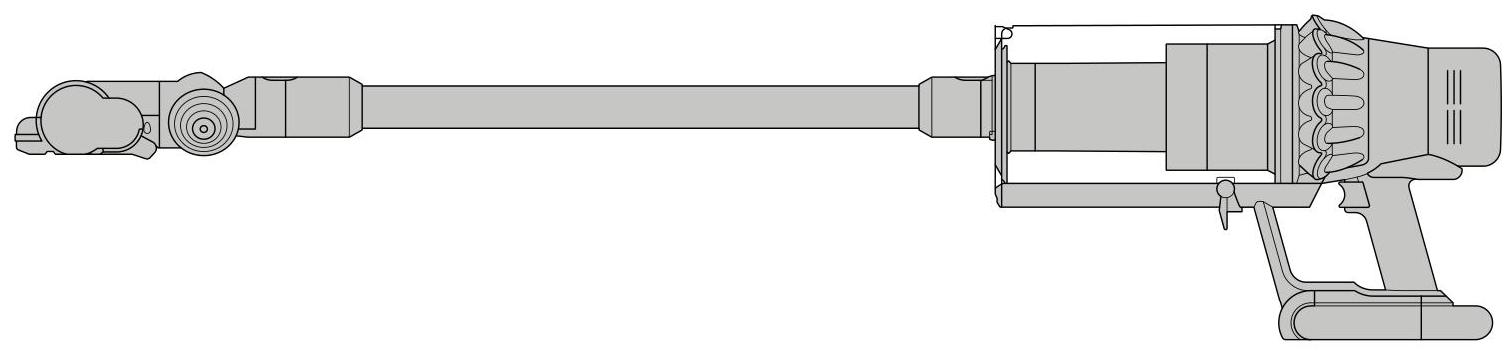

────────────────────────────────────────────────────────────
🖼️  img-1.jpeg (image/jpeg)
   Descripción: Cuerpo principal de la aspiradora....



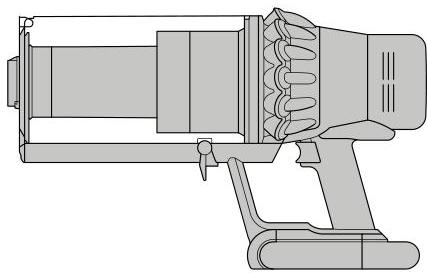

────────────────────────────────────────────────────────────
🖼️  img-2.jpeg (image/jpeg)
   Descripción: Cepillo High Torque XL: cepillo extra ancho de 12 pulgadas equipado con sistema Dyson DLS™ (Dynamic Load Sensor)....



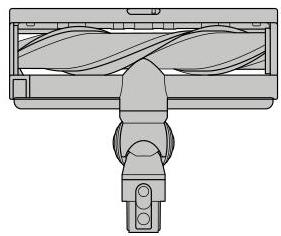

────────────────────────────────────────────────────────────
🖼️  img-3.jpeg (image/jpeg)
   Descripción: Cepillo High Torque XL extra ancho de 12 pulgadas, equipado con el sistema Dyson DLS™ (Dynamic Load Sensor) para ajustar automáticamente la potencia según el tipo de suelo....



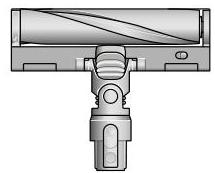

────────────────────────────────────────────────────────────
🖼️  img-4.jpeg (image/jpeg)
   Descripción: Base de carga fijada a la pared para almacenar y cargar la aspiradora....



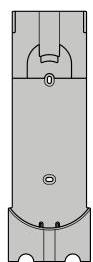

────────────────────────────────────────────────────────────


In [22]:
from IPython.display import display, Image as IPImage

# Mostrar las primeras N imágenes con su descripción enriquecida
MAX_PREVIEW = 5

print(f"Mostrando {min(MAX_PREVIEW, len(extracted_images))} de {len(extracted_images)} imágenes extraídas:\n")
for img in extracted_images[:MAX_PREVIEW]:
    print(f"🖼️  {img['id']} ({img['mime_type']})")
    print(f"   Descripción: {img['alt'][:180]}...")
    print()
    display(IPImage(data=img["bytes"], format=img["mime_type"].split("/")[-1]))
    print("─" * 60)


### 4.3 Embeddings visuales (imagen + descripción)

El embedding multimodal para imágenes combina **dos señales** en un único vector:

1. **La imagen en bytes** → captura contenido visual (colores, formas, objetos)
2. **La descripción enriquecida (texto)** → ancla la imagen en vocabulario semántico

Al enviarlos juntos dentro de un mismo `Content`, Gemini los fusiona en **un solo embedding** que es más rico que cualquiera de los dos por separado. Esto hace que la imagen sea recuperable tanto con queries visuales como con queries textuales.

> **Nota:** Esta es la razón por la que el paso de enriquecimiento en la Sección 2 es tan importante. Si la descripción es vaga, el embedding visual pierde potencia semántica.

In [23]:
# 4.3 Generar embeddings multimodales para imágenes
# Cada embedding combina la imagen en bytes + su descripción semántica
# → un único vector de 3072 dims que captura tanto el contenido visual como el semántico

image_embeddings = []

if extracted_images:
    print(f"Generando embeddings multimodales para {len(extracted_images)} imágenes...")
    for i, img in enumerate(extracted_images):
        response = gemini_client.models.embed_content(
            model=EMBEDDING_MODEL,
            contents=[
                types.Content(
                    parts=[
                        # La descripción enriquecida ancla la imagen en vocabulario semántico
                        types.Part.from_text(text=img["alt"]),
                        # Los bytes de la imagen aportan la señal visual
                        types.Part.from_bytes(data=img["bytes"], mime_type=img["mime_type"]),
                    ]
                )
            ],
            config=types.EmbedContentConfig(task_type="RETRIEVAL_DOCUMENT"),
        )
        image_embeddings.append(response.embeddings[0].values)

        if (i + 1) % 10 == 0 or (i + 1) == len(extracted_images):
            print(f"  Progreso: {i + 1}/{len(extracted_images)}", end="\r")

    print(f"\n✅ {len(image_embeddings)} embeddings visuales generados")
    print(f"📐 Dimensiones: {len(image_embeddings[0])} (mismo espacio que embeddings de texto)")
else:
    print("⚠️ No hay imágenes para embeddear.")


Generando embeddings multimodales para 84 imágenes...
  Progreso: 84/84
✅ 84 embeddings visuales generados
📐 Dimensiones: 3072 (mismo espacio que embeddings de texto)


## 5. Índice Vectorial con ChromaDB

### ¿Por qué ChromaDB con metadata?

ChromaDB almacena cada ítem como un trío: `(embedding, documento_texto, metadata)`. La metadata es la clave que nos permite resolver el **problema central del RAG multimodal**:

**El problema del pool único:**  
Sin metadata, cuando buscamos con `k=10` en un pool mixto de 100 ítems (20 texto + 80 imágenes), los chunks de texto tienden a ganar en similitud de coseno contra queries de texto — porque su embedding fue generado puramente de texto, igual que la query. Las imágenes nunca llegan al top-K.

**La solución con metadata:**  
```python
collection.query(where={"type": "text"},  n_results=k_text)   # Siempre k_text chunks
collection.query(where={"type": "image"}, n_results=k_images) # Siempre k_images imágenes
```

Esto garantiza representación balanceada independientemente de la distribución de similitudes.

### 5.1 Estructura del índice

In [24]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./chroma_db_mistral_gemini_vision")
COLLECTION_NAME = "multimodal_rag"

try:
    chroma_client.delete_collection(name=COLLECTION_NAME)
except:
    pass

collection = chroma_client.create_collection(name=COLLECTION_NAME, metadata={"hnsw:space": "cosine"})

# -------------------------------------------------------------------
# MEJORA 1: Metadata explícita por tipo para habilitar dual retrieval
# -------------------------------------------------------------------
text_metadatas = [{"type": "text", "chunk_index": i} for i in range(len(chunks))]
image_metadatas = [
    {"type": "image", "image_id": img["id"], "alt": img["alt"][:500]}
    for img in extracted_images
]
all_metadatas = text_metadatas + image_metadatas

# -------------------------------------------------------------------
# MEJORA 2: Documento de imagen = solo la descripción semántica rica
# (eliminar el prefijo "[Contenedor de Imagen] id |" que añade ruido)
# -------------------------------------------------------------------
image_documents = [img["alt"] for img in extracted_images]
all_documents   = chunks + image_documents

all_embeddings = text_embeddings + image_embeddings
all_ids        = [f"chunk_{i}" for i in range(len(chunks))] + [img["id"] for img in extracted_images]

collection.add(
    documents=all_documents,
    embeddings=all_embeddings,
    metadatas=all_metadatas,
    ids=all_ids,
)

print(f"✅ DB Multimodal lista. Colección incluye {collection.count()} entidades en la misma geometría.")
print(f"   📝 {len(chunks)} chunks de texto  |  🖼️  {len(extracted_images)} imágenes indexadas")

# Diccionario en memoria para acceso O(1) a bytes de imagen
images_dict = {img["id"]: img for img in extracted_images}


✅ DB Multimodal lista. Colección incluye 103 entidades en la misma geometría.
   📝 19 chunks de texto  |  🖼️  84 imágenes indexadas


### 5.2 Exportar imágenes a disco para la app web

ChromaDB guarda embeddings y metadata, pero **no los bytes de las imágenes**. Para que la interfaz web pueda mostrarlas, las guardamos como archivos y creamos un `image_manifest.json` que el chat app puede cargar.

In [25]:
import json
import os

# Directorio donde se guardarán las imágenes
IMAGES_DIR = "./extracted_images"
os.makedirs(IMAGES_DIR, exist_ok=True)

manifest = []
for img in extracted_images:
    # Guardar imagen como archivo binario
    img_path = os.path.join(IMAGES_DIR, img["id"])
    with open(img_path, "wb") as f:
        f.write(img["bytes"])

    manifest.append({
        "id":        img["id"],
        "alt":       img["alt"],
        "mime_type": img["mime_type"],
        "path":      img_path,
    })

# Guardar manifest (el chat app lo carga en startup)
with open("image_manifest.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print(f"✅ {len(manifest)} imágenes exportadas en '{IMAGES_DIR}/'")
print(f"✅ Manifest guardado en 'image_manifest.json'")
print(f"\nLa app web puede arrancarse con:")
print(f"  python chat_rag_multimodal.py")


✅ 84 imágenes exportadas en './extracted_images/'
✅ Manifest guardado en 'image_manifest.json'

La app web puede arrancarse con:
  python chat_rag_multimodal.py


## 6. Consulta con RAG Dual-Retrieval (True Multimodal RAG)

En lugar de buscar en un pool único donde el texto domina, usamos **dual retrieval**:

- **Consulta 1 → solo texto** (`where={"type": "text"}`) : recupera los `k_text` chunks más relevantes.  
- **Consulta 2 → solo imágenes** (`where={"type": "image"}`) : recupera las `k_images` imágenes más relevantes.

Esto **garantiza** que siempre haya imágenes relevantes en el contexto, independientemente de cuántos chunks de texto existan.

In [27]:
from IPython.display import display, Image
import base64

def responder_pregunta_multimodal(
    pregunta: str,
    collection,
    gemini_client,
    images_dict: dict,
    k_text: int = 4,
    k_images: int = 4,
):
    """
    RAG multimodal con dual retrieval.
    
    Consulta el índice de TEXTO y el de IMÁGENES por separado usando metadatos,
    garantizando siempre k_text chunks + k_images imágenes como contexto para Gemini.
    
    Args:
        pregunta:     Pregunta del usuario.
        collection:   Colección ChromaDB con metadatos de tipo.
        gemini_client: Cliente Gemini.
        images_dict:  Diccionario {image_id: image_data}.
        k_text:       Número de chunks de texto a recuperar.
        k_images:     Número de imágenes a recuperar.
    """
    # ----------------------------------------------------------------
    # 1. Embed de la pregunta con RETRIEVAL_QUERY
    # ----------------------------------------------------------------
    query_emb = gemini_client.models.embed_content(
        model=EMBEDDING_MODEL,
        contents=pregunta,
        config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
    )
    query_vector = query_emb.embeddings[0].values

    # ----------------------------------------------------------------
    # 2. DUAL RETRIEVAL: texto e imágenes por separado
    # ----------------------------------------------------------------
    # Ajustar k para no superar el número de ítems disponibles
    n_text_docs   = collection.count() - len(images_dict)
    n_image_docs  = len(images_dict)
    k_text_safe   = min(k_text,  max(1, n_text_docs))
    k_images_safe = min(k_images, max(1, n_image_docs))

    text_results = collection.query(
        query_embeddings=[query_vector],
        n_results=k_text_safe,
        where={"type": "text"},
    )
    image_results = collection.query(
        query_embeddings=[query_vector],
        n_results=k_images_safe,
        where={"type": "image"},
    )

    context_parts  = []   # partes para Gemini (imágenes como bytes)
    text_context   = []   # log de lo que se incluyó

    # ----------------------------------------------------------------
    # 3. Procesar resultados de TEXTO
    # ----------------------------------------------------------------
    print("--- CHUNKS DE TEXTO RECUPERADOS ---")
    for doc, doc_id, dist in zip(
        text_results["documents"][0],
        text_results["ids"][0],
        text_results["distances"][0],
    ):
        similitud = 1.0 - dist
        texto_preview = doc[:120].replace("\n", " ")
        print(f"  📄 {doc_id}  (similitud: {similitud:.4f}) → {texto_preview}...")
        text_context.append(f"[TEXTO | {doc_id} | sim={similitud:.4f}]\n{doc}")

    # ----------------------------------------------------------------
    # 4. Procesar resultados de IMÁGENES
    # ----------------------------------------------------------------
    print("\n--- IMÁGENES RECUPERADAS POR SIMILITUD ---")
    imagenes_mostradas = 0
    for doc, doc_id, dist in zip(
        image_results["documents"][0],
        image_results["ids"][0],
        image_results["distances"][0],
    ):
        similitud = 1.0 - dist
        if doc_id in images_dict:
            img_data = images_dict[doc_id]
            part = types.Part.from_bytes(data=img_data["bytes"], mime_type=img_data["mime_type"])
            context_parts.append(part)
            text_context.append(
                f"[IMAGEN | {doc_id} | sim={similitud:.4f}]\nDescripción: {img_data['alt']}"
            )
            print(f"  🖼️  {doc_id}  (similitud: {similitud:.4f})")
            display(Image(data=img_data["bytes"], format=img_data["mime_type"].split("/")[-1]))
            imagenes_mostradas += 1

    if imagenes_mostradas == 0:
        print("  ⚠️  No hay imágenes en el índice, o k_images=0.")

    # ----------------------------------------------------------------
    # 5. Construir prompt contextual
    # ----------------------------------------------------------------
    context_unified = "\n\n".join(text_context)
    prompt_texto = f"""Responde la pregunta basándote en el contexto de texto y las imágenes adjuntas.

<PREGUNTA>
{pregunta}
</PREGUNTA>

<CONTEXTO>
{context_unified}
</CONTEXTO>
"""
    # El prompt de texto va PRIMERO; las partes de imagen le siguen
    context_parts.insert(0, prompt_texto)

    # ----------------------------------------------------------------
    # 6. Generación multimodal con Gemini
    # ----------------------------------------------------------------
    respuesta = gemini_client.models.generate_content(
        model="gemini-3.1-flash-lite-preview",
        contents=context_parts,
    )

    return respuesta.text, context_unified


### 6.1 Prueba con una pregunta procedimental

Hacemos primero una pregunta de proceso — el tipo donde tipicamente la respuesta incluye **texto instruccional + diagramas o fotos de los pasos**. 

> Ajusta `K_TEXT` y `K_IMAGES` según cuánto contexto quieres darle a Gemini.  
> Para documentos técnicos, `k_images=3–5` suele ser suficiente sin saturar el contexto.

--- CHUNKS DE TEXTO RECUPERADOS ---
  📄 chunk_10  (sim: 0.6930) → la máquina te lo indique. 1 ![img-42.jpeg](img-42.jpeg) ![img-43.jpeg](img-43.jpeg) Retira la unidad...
  📄 chunk_11  (sim: 0.6585) → de agua y déjalo secar con la parte de espuma hacia arriba. Deja secar el filtro en un entorno seco ...
  📄 chunk_9  (sim: 0.6297) → el cubo, vacíalo como se muestra en el apartado «Vaciado del cubo». Pulsa el botón rojo en la guía d...
  📄 chunk_12  (sim: 0.6223) → lavadora, la secadora, el horno, el microondas o junto a una llama abierta. Usa únicamente agua fría...

--- IMÁGENES RECUPERADAS POR SIMILITUD ---
  🖼️  img-48.jpeg  (sim: 0.4849)


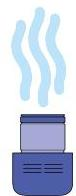

  🖼️  img-44.jpeg  (sim: 0.4830)


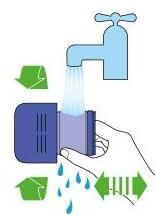

  🖼️  img-45.jpeg  (sim: 0.4793)


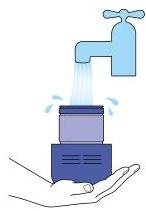

  🖼️  img-49.jpeg  (sim: 0.4482)


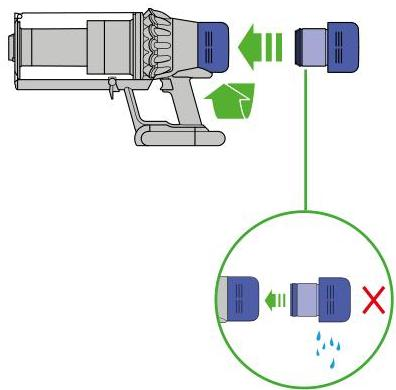

In [28]:
# Ejemplo directo de dual retrieval (misma lógica que responder_pregunta_multimodal)
pregunta = "Como se lleva el proceso de Lavado del filtro?"
K_TEXT   = 4
K_IMAGES = 4

# 1. Embed de la query
query_emb = gemini_client.models.embed_content(
    model=EMBEDDING_MODEL,
    contents=pregunta,
    config=types.EmbedContentConfig(task_type="RETRIEVAL_QUERY"),
)
query_vector = query_emb.embeddings[0].values

# 2. Dual retrieval separado por metadata
text_results  = collection.query(query_embeddings=[query_vector], n_results=K_TEXT,   where={"type": "text"})
image_results = collection.query(query_embeddings=[query_vector], n_results=K_IMAGES, where={"type": "image"})

context_parts = []
text_context  = []

# 3. Mostrar chunks de texto recuperados
print("--- CHUNKS DE TEXTO RECUPERADOS ---")
for doc, doc_id, dist in zip(text_results["documents"][0], text_results["ids"][0], text_results["distances"][0]):
    similitud = 1.0 - dist
    print(f"  📄 {doc_id}  (sim: {similitud:.4f}) → {doc[:100].replace(chr(10), ' ')}...")
    text_context.append(f"[TEXTO | {doc_id} | sim={similitud:.4f}]\n{doc}")

# 4. Mostrar imágenes recuperadas
print("\n--- IMÁGENES RECUPERADAS POR SIMILITUD ---")
imagenes_mostradas = 0
for doc, doc_id, dist in zip(image_results["documents"][0], image_results["ids"][0], image_results["distances"][0]):
    similitud = 1.0 - dist
    if doc_id in images_dict:
        img_data = images_dict[doc_id]
        context_parts.append(types.Part.from_bytes(data=img_data["bytes"], mime_type=img_data["mime_type"]))
        text_context.append(f"[IMAGEN | {doc_id} | sim={similitud:.4f}]\nDescripción: {img_data['alt']}")
        print(f"  🖼️  {doc_id}  (sim: {similitud:.4f})")
        display(Image(data=img_data["bytes"], format=img_data["mime_type"].split("/")[-1]))
        imagenes_mostradas += 1

if imagenes_mostradas == 0:
    print("  ⚠️  No hay imágenes indexadas o k_images=0.")

context_unified = "\n\n".join(text_context)


### 6.2 Prueba con una pregunta de identificación visual

Esta pregunta requiere que el modelo "vea" el producto. Sin imágenes en el contexto, la respuesta sería genérica. Con el dual retrieval, Gemini recibe las imágenes más similares junto con el texto relevante.

--- CHUNKS DE TEXTO RECUPERADOS ---
  📄 chunk_7  (similitud: 0.6989) → pantalla indique 100 %, la batería está completamente cargada. La máquina no funcionará ni se cargará si la temperatura ...
  📄 chunk_6  (similitud: 0.6975) → el modo automático/medio. Asegúrate de que ambas baterías estén cargadas. ## Alertas Cuando la batería necesite cargarse...
  📄 chunk_15  (similitud: 0.6754) → cabezal. Para seleccionar la succión necesaria, mueve el control deslizante sobre el cabezal. + Máxima succión para polv...
  📄 chunk_10  (similitud: 0.6631) → la máquina te lo indique. 1 ![img-42.jpeg](img-42.jpeg) ![img-43.jpeg](img-43.jpeg) Retira la unidad del filtro girando ...

--- IMÁGENES RECUPERADAS POR SIMILITUD ---
  🖼️  img-7.jpeg  (similitud: 0.5037)


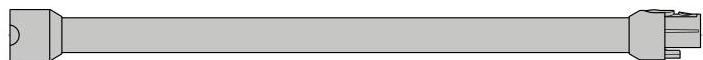

  🖼️  img-5.jpeg  (similitud: 0.4884)


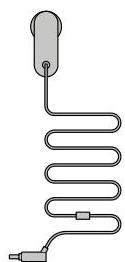

  🖼️  img-4.jpeg  (similitud: 0.4799)


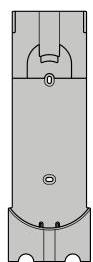

  🖼️  img-32.jpeg  (similitud: 0.4767)


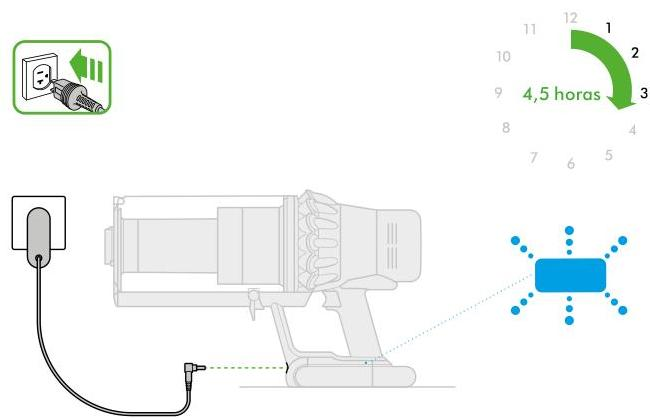

**TU PREGUNTA:** como funciona y como se ve el cargador de bateria de la aspiradora?

**RESPUESTA DE GEMINI:**

Basado en el contexto y las imágenes proporcionadas, aquí tienes los detalles sobre el cargador de la aspiradora:

### ¿Cómo se ve?
El sistema de carga consta de los siguientes elementos visuales:
*   **Cable de alimentación:** Es un cable que incluye un transformador y un conector específico para cargar la batería (se muestra en `img-5.jpeg` y `img-7.jpeg`).
*   **Base de carga:** Es una estructura diseñada para fijarse a la pared, la cual permite almacenar la aspiradora mientras se carga (se muestra en `img-4.jpeg`).

### ¿Cómo funciona?
*   **Modos de conexión:** Puedes cargar la máquina conectando el cable de alimentación directamente a la batería o utilizando la base de carga fijada a la pared.
*   **Proceso de carga:** La carga completa requiere aproximadamente **4,5 horas**.
*   **Indicadores visuales:** 
    *   Mientras la batería se está cargando, los LED azules situados a cada lado de la batería parpadearán. 
    *   Cuando la carga está completa, los LED se iluminarán de forma fija durante cinco segundos y la pantalla de la aspiradora indicará "100 %".
*   **Condiciones importantes:** La máquina no se cargará si la temperatura ambiente es inferior a 10°C, esto como medida de protección para el motor y la batería. Es recomendable cargar la máquina totalmente después de cada uso para que el sistema de monitoreo de la batería aprenda y calcule con mayor precisión la autonomía restante.



--- LOGS: QUÉ VIO GEMINI (CONTEXTO APROVECHADO) ---
[TEXTO | chunk_7 | sim=0.6989]
pantalla indique 100 %, la batería está completamente cargada. La máquina no funcionará ni se cargará si la temperatura ambiente es inferior a 10°C, para proteger así tanto el motor como la batería. # Cambio de la batería intercambiable Si tienes baterías adicionales, te recomendamos que las alternes para mantener un rendimiento uniforme. ![img-33.jpeg](img-33.jpeg) Para extraer la batería Pon la mano bajo la batería para sujetarla. Pulsa el botón rojo de extracción de la batería y deslízala por el mango. Pon la batería a cargar. ![img-34.jpeg](img-34.jpeg) Para instalar una batería Vuelve a deslizar la batería por el mango hasta que haga un clic cuando esté en su sitio. Vaciado del cubo Vacía el cubo en cuanto la suciedad alcance la marca «MAX»; no la superes nunca. Utilizar la máquina cuando la suciedad supera la marca «MAX» puede hacer que la suciedad llegue al filtro y que sea necesario un mantenim

In [29]:
pregunta_usuario = "como funciona y como se ve el cargador de bateria de la aspiradora?"

try:
    respuesta, contexto_usado = responder_pregunta_multimodal(
        pregunta_usuario,
        collection,
        gemini_client,
        images_dict,
        k_text=4,
        k_images=4,
    )
    display(Markdown(f"**TU PREGUNTA:** {pregunta_usuario}"))
    display(Markdown(f"**RESPUESTA DE GEMINI:**\n\n{respuesta}"))

    print("\n\n--- LOGS: QUÉ VIO GEMINI (CONTEXTO APROVECHADO) ---")
    print(contexto_usado)
except Exception as e:
    print("Asegúrate de procesar correctamente las celdas anteriores :)", e)


## 7. Conclusión y Próximos Pasos

### Lo que construiste

Has implementado un sistema RAG multimodal de producción que resuelve el problema más común en este dominio — **la invisibilidad de las imágenes** en sistemas que usan un pool vectorial único.

| Componente | Tecnología | Rol |
|---|---|---|
| OCR | Mistral OCR 3 `mistral-ocr-latest` | Extrae texto + imágenes del PDF |
| Enriquecimiento visual | Gemini 3.1 Flash Lite| Genera descripciones semánticas de cada imagen |
| Embeddings | `gemini-embedding-2-preview` | Proyecta texto e imágenes al mismo espacio vectorial |
| Índice | ChromaDB con metadata | Almacena y filtra por tipo de contenido |
| Recuperación | Dual Retrieval (`where` filter) | Garantiza `k_text` + `k_images` por consulta |
| Generación | Gemini 2.5 Flash (multimodal) | Responde usando texto e imágenes como contexto |

---

### Extensiones sugeridas

**Mejorar la calidad de recuperación:**
- **Reranking:** Después del dual retrieval, usa un cross-encoder para reordenar los resultados antes de enviarlos a Gemini
- **Query expansion:** Genera variantes de la pregunta del usuario y promedia los embeddings para mayor robustez
- **Threshold de similitud:** Filtra imágenes con similitud < 0.4 para no introducir contexto irrelevante

**Escalar a producción:**
- **Chunking semántico:** Reemplaza el chunking por palabras con `semantic-text-splitter` para preservar párrafos completos
- **Procesamiento en lotes asíncrono:** Usa `asyncio` para procesar múltiples PDFs en paralelo
- **Persistencia cross-session:** ChromaDB ya es persistente; solo recarga con `PersistentClient` sin `delete_collection`

**Mejorar la experiencia:**
- **Citar fuentes:** Incluye en la respuesta el ID de página y el ID de imagen usados
- **UI con Gradio/Streamlit:** Convierte el notebook en una app web en ~50 líneas adicionales
- **Soporte de formatos:** Extiende `pdf_to_base64()` para aceptar imágenes `.png/.jpg` directamente

### Apéndice: ¿Por qué el dual retrieval resuelve el problema?

| Problema (pool único) | Solución (dual retrieval) |
|---|---|
| Texto domina cosine similarity vs. queries de texto | Queries separadas con `where={"type":"text"}` y `where={"type":"image"}` |
| Sin metadata → imposible filtrar por tipo | `metadatas=[{"type":"text"/"image"}, ...]` al indexar |
| Documento de imagen = prefijo ruidoso `[Contenedor de Imagen] id \|` | Documento de imagen = solo la descripción semántica generada por Gemini |
| `k` global competitivo → imágenes fuera del top-K | `k_text` + `k_images` independientes y garantizados |

```
Sin dual retrieval (k=10):          Con dual retrieval (k_text=4, k_images=4):
┌──────────────────────┐            ┌──────────────────┬─────────────────┐
│  Top 10 resultados   │            │   4 chunks texto │  4 imágenes     │
│  ────────────────    │            │  ───────────────  │  ────────────── │
│  chunk_0 (0.91)      │            │  chunk_0 (0.91)  │  img-3 (0.72)   │
│  chunk_5 (0.88)      │            │  chunk_5 (0.88)  │  img-12 (0.69)  │
│  chunk_3 (0.85)      │            │  chunk_3 (0.85)  │  img-7 (0.65)   │
│  chunk_8 (0.83)      │            │  chunk_8 (0.83)  │  img-1 (0.61)   │
│  chunk_2 (0.81)      │            └──────────────────┴─────────────────┘
│  chunk_7 (0.79)      │
│  chunk_4 (0.77)      │            → Gemini siempre ve texto + imágenes
│  chunk_9 (0.76)      │
│  chunk_1 (0.74)      │
│  chunk_6 (0.71)      │
│  ← 0 imágenes        │
└──────────────────────┘
```